In [ ]:
# google Drive mount
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/DrowsyDriverData/FatigueDriver Dataset.zip"
extract_path = "/content/drive/MyDrive/DrowsyDriverData"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
    print("Unzipping complete")

for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))

In [ ]:
from tqdm import tqdm
import zipfile
import os
from ultralytics import YOLO
import shutil
import random
import cv2
import numpy as np
import yaml
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from glob import glob
from google.colab.patches import cv2_imshow
from IPython.display import display, clear_output
import PIL.Image
from google.colab import files

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
!git clone http://github.com/ultralytics/ultralytics.git

Cloning into 'ultralytics'...
remote: Enumerating objects: 76151, done.
remote: Counting objects: 100% (338/338), done.
remote: Compressing objects: 100% (124/124), done.
remote: Total 76151 (delta 283), reused 215 (delta 214), pack-reused 75813 (from 2)
Receiving objects: 100% (76151/76151), 40.70 MiB | 16.89 MiB/s, done.
Resolving deltas: 100% (57223/57223), done.


In [ ]:
!pip install tqdm
!pip install torch torchvision numpy matplotlib
!pip install ultralytics
!pip install ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 60.1 MB/s eta 0:00:00


In [ ]:
# yolov11n.pt
!pip freeze > requirements.txt
!yolo predict

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
WARNING ⚠️ 'model' argument is missing. Using default 'model=yolo11n.pt'.
WARNING ⚠️ 'source' argument is missing. Using default 'source=/usr/local/lib/python3.12/dist-packages/ultralytics/assets'.
Ultralytics 8.3.225 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

image 1/2 /usr/local/lib/python3.12/dist-packages/ultralytics/assets/bus.jpg: 640x480 4 persons, 1 bus, 107.4ms
image 2/2 /usr/local/lib/python3.12/dist-packages/ultralytics/assets/zidane.jpg: 384x640 2 persons, 1 tie, 72.0ms
Speed: 8.8ms preprocess, 89.7ms inference, 4.8ms postprocess per image at shape (1, 3, 384, 640)


In [ ]:
import os
import shutil
from glob import glob
from collections import defaultdict, Counter
import random, yaml

random.seed(42)

base_dir = '/content/drive/MyDrive/FireSD/forestfireyolov11'
out_root = os.path.join(base_dir, 'forestfireyolov11_split701')
ratios = {'train': 0.7, 'valid': 0.2, 'test': 0.1}

def clean_make_dir(p):
    if os.path.exists(p):
        shutil.rmtree(p)
    os.makedirs(p, exist_ok=True)

for sp in ['train', 'valid', 'test']:
    clean_make_dir(os.path.join(out_root, sp, 'images'))
    clean_make_dir(os.path.join(out_root, sp, 'labels'))


IMG_PATS = ['**/*.jpg','**/*.jpeg','**/*.png','**/*.JPG','**/*.JPEG','**/*.PNG']

def rec_glob(root, patterns):
    paths = []
    for pat in patterns:
        paths += glob(os.path.join(root, pat), recursive=True)
    return [p for p in paths if os.path.isfile(p) and not os.path.abspath(p).startswith(os.path.abspath(out_root))]


all_images = rec_glob(base_dir, IMG_PATS)
all_labels = [p for p in rec_glob(base_dir, ['**/*.txt']) if not os.path.basename(p).startswith('.')]

print(f'발견: 이미지 {len(all_images)}개, 라벨 {len(all_labels)}개')


def basename_noext(p): return os.path.splitext(os.path.basename(p))[0]

image_index = {}
for ip in all_images:
    b = basename_noext(ip)
    image_index.setdefault(b, ip)

def read_primary_class(label_path):
    with open(label_path, 'r') as f:
        for line in f:
            s = line.strip()
            if not s:
                continue
            return s.split()[0]
    return None

def add_all_classes(label_path, class_set):
    with open(label_path, 'r') as f:
        for line in f:
            s = line.strip()
            if not s:
                continue
            try:
                class_set.add(int(s.split()[0]))
            except:
                pass

dataset = []
all_classes_set = set()
missing_img = 0
for lp in all_labels:
    b = basename_noext(lp)
    ip = image_index.get(b, None)
    if ip is None:
        missing_img += 1
        continue
    primary = read_primary_class(lp)
    if primary is None:
        continue
    add_all_classes(lp, all_classes_set)
    dataset.append((lp, ip, primary))

print(f'매칭 성공: {len(dataset)}  |  이미지 못 찾은 라벨: {missing_img}')
if len(dataset) == 0:
    raise SystemExit("라벨-이미지 매칭 결과가 0개입니다. 폴더 구조를 확인하세요.")

by_class = defaultdict(list)
for lp, ip, cls in dataset:
    by_class[cls].append((lp, ip))

assignments = defaultdict(list)
for cls, items in by_class.items():
    random.shuffle(items)
    n = len(items)
    n_train = int(n * ratios['train'])
    n_valid = int(n * ratios['valid'])
    split_map = {
        'train': items[:n_train],
        'valid': items[n_train:n_train+n_valid],
        'test' : items[n_train+n_valid:],
    }
    for sp, arr in split_map.items():
        assignments[sp].extend(arr)

def copy_pair(lbl_src, img_src, split):
    dst_lbl = os.path.join(out_root, split, 'labels', os.path.basename(lbl_src))
    dst_img = os.path.join(out_root, split, 'images', os.path.basename(img_src))
    shutil.copy2(lbl_src, dst_lbl)
    shutil.copy2(img_src, dst_img)

for sp in ['train', 'valid', 'test']:
    for lp, ip in assignments[sp]:
        copy_pair(lp, ip, sp)

yaml_candidates = [
    os.path.join(base_dir, 'data.yaml'),
    os.path.join(base_dir, 'dataset.yaml'),
]
names = None
for yc in yaml_candidates:
    if os.path.exists(yc):
        try:
            with open(yc, 'r') as f:
                dy = yaml.safe_load(f)
            if isinstance(dy, dict) and 'names' in dy:
                names = dy['names']
                break
        except Exception:
            pass

if names is None:
    nc = max(all_classes_set) + 1 if all_classes_set else 1
    names = [f'class_{i}' for i in range(nc)]

data_yaml = {
    'path': out_root,
    'train': 'train/images',
    'val':   'valid/images',   # 키는 'val'
    'test':  'test/images',
    'names': names
}
with open(os.path.join(out_root, 'data.yaml'), 'w') as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False, allow_unicode=True)

print('data.yaml 저장 완료 ->', os.path.join(out_root, 'data.yaml'))

def count_primary_classes_in_dir(lbl_dir):
    cnt = Counter()
    for lf in glob(os.path.join(lbl_dir, '*.txt')):
        with open(lf, 'r') as f:
            for line in f:
                s = line.strip()
                if not s:
                    continue
                cnt[s.split()[0]] += 1
                break
    return dict(sorted(cnt.items(), key=lambda x: int(x[0])))

def folder_count(pat):
    return len([p for p in glob(pat) if os.path.isfile(p)])

print('\n=== 분할 결과 ===')
for sp in ['train','valid','test']:
    n_img = folder_count(os.path.join(out_root, sp, 'images', '*'))
    n_lbl = folder_count(os.path.join(out_root, sp, 'labels', '*.txt'))
    cls_dist = count_primary_classes_in_dir(os.path.join(out_root, sp, 'labels'))
    print(f'[{sp}] images={n_img}, labels={n_lbl}, 대표클래스분포={cls_dist}')

print('\n🎯 이제 학습 가능 예시:')
print(f"from ultralytics import YOLO\nm=YOLO('yolov11n.pt')\n"
      f"m.train(data='{os.path.join(out_root, 'data.yaml')}', epochs=100, imgsz=640)")


In [ ]:
!pwd
from glob import glob

train_img_list = glob('/content/drive/MyDrive/FireSD/forestfireyolov11_split701/train/images/*.jpg')
train_txt_list = glob('/content/drive/MyDrive/FireSD/forestfireyolov11_split701/train/labels/*.txt')

test_img_list = glob('/content/drive/MyDrive/FireSD/forestfireyolov11_split701/test/images/*.jpg')
test_txt_list = glob('/content/drive/MyDrive/FireSD/forestfireyolov11_split701/test/labels/*.txt')

valid_img_list = glob('/content/drive/MyDrive/FireSD/forestfireyolov11_split701/valid/images/*.jpg')
valid_txt_list = glob('/content/drive/MyDrive/FireSD/forestfireyolov11_split701/valid/labels/*.txt')

print(len(train_img_list), len(train_txt_list))
print(len(test_img_list), len(test_txt_list))
print(len(valid_img_list), len(valid_txt_list))

/content
2979 2978
430 430
851 850


In [ ]:
import os
from glob import glob
from collections import Counter

label_dirs = [
    '/content/drive/MyDrive/FireSD/forestfireyolov11_split701/train/labels',
    '/content/drive/MyDrive/FireSD/forestfireyolov11_split701/test/labels',
    '/content/drive/MyDrive/FireSD/forestfireyolov11_split701/valid/labels'
]

class_counter = Counter()

for label_dir in label_dirs:
    txt_files = glob(os.path.join(label_dir, '*.txt'))
    for txt_path in txt_files:
        with open(txt_path, 'r') as f:
            for line in f:
                cls = line.strip().split()[0]
                class_counter[cls] += 1

print("클래스별 개수:")
for cls_id, count in sorted(class_counter.items(), key=lambda x: int(x[0])):
    print(f"클래스 {cls_id}: {count}개")

클래스별 개수:
클래스 0: 1514개
클래스 1: 884개
클래스 2: 1282개
클래스 3: 892개
클래스 4: 4452개
클래스 5: 1000개


In [ ]:
with open('/content/drive/MyDrive/FireSD/forestfireyolov11_split701/train/train.txt', 'w') as f:
    f.write('\n'.join(train_img_list) + '\n')

with open('/content/drive/MyDrive/FireSD/forestfireyolov11_split701/valid/val.txt', 'w') as f:
    f.write('\n'.join(valid_img_list) + '\n')

In [ ]:
import os, glob, yaml, textwrap

out_root = '/content/drive/MyDrive/FireSD/forestfireyolov11_split701'
yaml_path = os.path.join(out_root, 'data.yaml')

names_default = ['class_0','class_1','class_2','class_3','class_4']
data_yaml = {
    'path': out_root,
    'train': 'train/images',
    'val':   'valid/images',
    'test':  'test/images',
    'names': names_default
}
os.makedirs(out_root, exist_ok=True)
with open(yaml_path, 'w') as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False, allow_unicode=True)
print('data.yaml 갱신 완료:', yaml_path)
print(textwrap.indent(yaml.safe_dump(data_yaml, sort_keys=False, allow_unicode=True), prefix='  '))

def check_dir(pat):
    files = sorted([p for p in glob.glob(pat) if os.path.isfile(p)])
    return len(files), files[:5]

checks = {
    'train_images': os.path.join(out_root, 'train', 'images', '*'),
    'train_labels': os.path.join(out_root, 'train', 'labels', '*.txt'),
    'val_images':   os.path.join(out_root, 'valid', 'images', '*'),
    'val_labels':   os.path.join(out_root, 'valid', 'labels', '*.txt'),
    'test_images':  os.path.join(out_root, 'test', 'images', '*'),
    'test_labels':  os.path.join(out_root, 'test', 'labels', '*.txt'),
}

print('\n 폴더별 파일 수(상위 5개 예시):')
for k, pat in checks.items():
    n, sample = check_dir(pat)
    print(f'  - {k}: {n} files')
    if sample:
        for s in sample:
            print('     •', s)

problems = []
if not os.path.exists(os.path.join(out_root, 'train', 'images')):
    problems.append("train/images 폴더가 없음")
if not os.path.exists(os.path.join(out_root, 'valid', 'images')):
    problems.append("valid/images 폴더가 없음 (키는 val이어야 함)")
if not os.path.exists(os.path.join(out_root, 'test', 'images')):
    problems.append("test/images 폴더가 없음")

def count_glob(pat): return len(glob.glob(pat))

if count_glob(checks['train_images']) == 0: problems.append("train/images에 이미지가 없음")
if count_glob(checks['val_images'])   == 0: problems.append("valid/images에 이미지가 없음")
if count_glob(checks['test_images'])  == 0: problems.append("test/images에 이미지가 없음")
if count_glob(checks['train_labels']) == 0: problems.append("train/labels에 라벨이 없음")
if count_glob(checks['val_labels'])   == 0: problems.append("valid/labels에 라벨이 없음")
if count_glob(checks['test_labels'])  == 0: problems.append("test/labels에 라벨이 없음")

if problems:
    print("\n 점검 필요 항목:")
    for p in problems:
        print("  -", p)
else:
    print("\n 디렉터리/파일 구성 OK. 이제 학습을 실행해도 됩니다.")

In [ ]:
AUG = dict(
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.5,
    mosaic=1.0, mixup=0.15, copy_paste=0.3,
    degrees=0.0, translate=0.08, scale=0.5, shear=0.0, perspective=0.0,
)

TRAIN = dict(
    imgsz=960, epochs=80, batch=16, optimizer='AdamW',
    lr0=0.01, lrf=0.1, weight_decay=0.0005, patience=20
)

LOSS = dict(
    box=7.5, cls=0.5, dfl=1.5,
    fl_gamma=1.5
)
print("AUG:", AUG); print("TRAIN:", TRAIN); print("LOSS:", LOSS)

AUG: {'hsv_h': 0.015, 'hsv_s': 0.7, 'hsv_v': 0.5, 'mosaic': 1.0, 'mixup': 0.15, 'copy_paste': 0.3, 'degrees': 0.0, 'translate': 0.08, 'scale': 0.5, 'shear': 0.0, 'perspective': 0.0}
TRAIN: {'imgsz': 960, 'epochs': 80, 'batch': 16, 'optimizer': 'AdamW', 'lr0': 0.01, 'lrf': 0.1, 'weight_decay': 0.0005, 'patience': 20}
LOSS: {'box': 7.5, 'cls': 0.5, 'dfl': 1.5, 'fl_gamma': 1.5}


In [ ]:
from glob import glob

base_dir = '/content/drive/MyDrive/FireSD/forestfireyolov11_split701'
img_files = glob(f'{base_dir}/**/*.jpg', recursive=True)

print(f"발견된 이미지 파일 수: {len(img_files)}")
for p in img_files[:20]:
    print(p)

발견된 이미지 파일 수: 4260
/content/drive/MyDrive/FireSD/forestfireyolov11_split701/train/images/Fire-480-_jpg.rf.ed051953407300cee78be5800dc11653.jpg
/content/drive/MyDrive/FireSD/forestfireyolov11_split701/train/images/fire-8805-59273821_png_jpg.rf.c7c7aa60456f90fdaa1ff150818e65f2.jpg
/content/drive/MyDrive/FireSD/forestfireyolov11_split701/train/images/images636_jpg.rf.c0b6330fcbf66cdf47041c3a8e71d09c.jpg
/content/drive/MyDrive/FireSD/forestfireyolov11_split701/train/images/798_549_760_777_301_638_1_956_781_322_558_934_768_700_172_218__png_jpg.rf.e134d8233745dd653b98620c5c7a90dc.jpg
/content/drive/MyDrive/FireSD/forestfireyolov11_split701/train/images/Smoke-259-_jpg.rf.c3638b9911e1ddacf81498a481e14f57.jpg
/content/drive/MyDrive/FireSD/forestfireyolov11_split701/train/images/Fire-932-_jpg.rf.ba691b58a8468dacd3e0a9b3b9fd4df8.jpg
/content/drive/MyDrive/FireSD/forestfireyolov11_split701/train/images/fire_0359_jpg.rf.b216a4d16aebe92d5335e4dc1bb4a863.jpg
/content/drive/MyDrive/FireSD/forestfireyo

In [ ]:
!pwd
!yolo task=detect mode=train model=/content/drive/MyDrive/FireSD/yolo11n.pt data=/content/drive/MyDrive/FireSD/forestfireyolov11_split701/data.yaml epochs=100 lr0=0.0005 lrf=0.01 batch=32 device=0 dropout=0.1 warmup_epochs=5 weight_decay=0.01 patience=10 imgsz=960 optimizer=ADAMW

/content
Ultralytics 8.3.230 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/FireSD/forestfireyolov11_split701/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/FireSD/yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimi

In [ ]:
%load_ext tensorboard
%tensorboard --logdir runs

In [ ]:
!yolo task=detect mode=val \
    model=/content/runs/detect/train/weights/best.pt \
    data=/content/drive/MyDrive/FireSD/forestfireyolov11_split701/data.yaml \
    split=test plots=True

Ultralytics 8.3.230 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
YOLO11n summary (fused): 100 layers, 2,583,322 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 0.1±0.0 MB/s, size: 58.1 KB)
val: Scanning /content/drive/MyDrive/FireSD/forestfireyolov11_split701/test/labels.cache... 430 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 430/430 5.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 3.6it/s 7.6s
                   all        430       1038      0.842       0.82      0.854      0.634
           large smoke        146        162      0.854      0.815      0.884      0.701
            large fire         76         89      0.834      0.789       0.92      0.734
           small smoke        107        126      0.765      0.706      0.754      0.564
           medium fire         79         93      0.751      0.753      0.743      0.515
            

In [ ]:
import pandas as pd

df = pd.read_csv('/content/runs/detect/train/results.csv')

for i, col in enumerate(df.columns):
    print(i, ":", repr(col))

0 : 'epoch'
1 : 'time'
2 : 'train/box_loss'
3 : 'train/cls_loss'
4 : 'train/dfl_loss'
5 : 'metrics/precision(B)'
6 : 'metrics/recall(B)'
7 : 'metrics/mAP50(B)'
8 : 'metrics/mAP50-95(B)'
9 : 'val/box_loss'
10 : 'val/cls_loss'
11 : 'val/dfl_loss'
12 : 'lr/pg0'
13 : 'lr/pg1'
14 : 'lr/pg2'


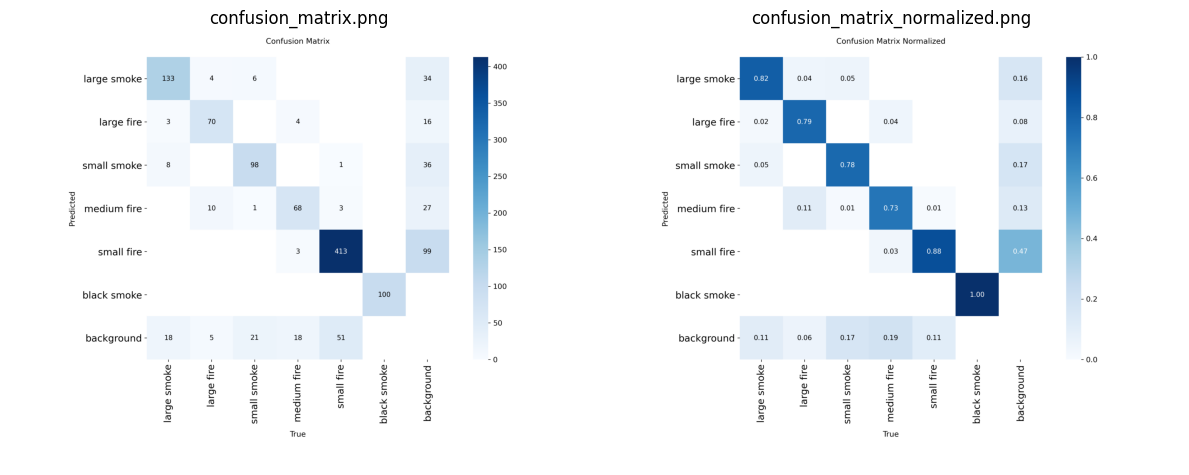

In [ ]:
import os, cv2, matplotlib.pyplot as plt, numpy as np

val_dir = "/content/runs/detect/val"

names = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "PR_curve.png",
    "F1_curve.png",
]

paths = [(n, os.path.join(val_dir, n)) for n in names if os.path.exists(os.path.join(val_dir, n))]

if not paths:
    raise FileNotFoundError("val 폴더에 시각화 이미지가 없습니다. 위 1) 셀을 먼저 실행해주세요.")

cols = 2
rows = int(np.ceil(len(paths)/cols))
plt.figure(figsize=(12, 6 if rows==1 else 10))

for i, (title, p) in enumerate(paths, 1):
    img = cv2.imread(p)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax = plt.subplot(rows, cols, i)
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/runs/detect/train/results.csv')
df.columns = df.columns.str.strip()

cols = [
    ('train/box_loss', 'train/box_loss'),
    ('train/cls_loss', 'train/cls_loss'),
    ('train/dfl_loss', 'train/dfl_loss'),
    ('metrics/precision(B)', 'metrics/precision(B)'),
    ('metrics/recall(B)', 'metrics/recall(B)'),
    ('val/box_loss', 'val/box_loss'),
    ('val/cls_loss', 'val/cls_loss'),
    ('val/dfl_loss', 'val/dfl_loss'),
    ('metrics/mAP50(B)', 'metrics/mAP50(B)'),
    ('metrics/mAP50-95(B)', 'metrics/mAP50-95(B)'),
]

def smooth(x, k=5):
    if k <= 1: return x
    return np.convolve(x, np.ones(k)/k, mode='same')

epochs = np.arange(len(df))

plt.figure(figsize=(16, 9))
for i, (title, key) in enumerate(cols, 1):
    if key not in df.columns: continue
    y = df[key].values
    ys = smooth(y, k=5)
    ax = plt.subplot(2, 5, i)
    ax.plot(epochs, y, label='results', linewidth=2)
    ax.plot(epochs, ys, linestyle='--', label='smooth', linewidth=2)
    ax.set_title(title)
    if 'metrics/' in key:
        ax.set_ylim(0, 1)
    if i == 2:
        ax.legend()

plt.tight_layout()
plt.show()
